In [ ]:
#@title 0. Import Frameworks:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


Dataset successfully loaded. Shape: (1471, 11)
label
healthy        500
imbalanced     500
obstruction    471
Name: count, dtype: int64
[OK] Đã nạp dữ liệu thành công!

--- Satistical Table ---
             The number of samples (Windows)  Percentage (%)
label                                                       
healthy                                  500       33.990483
imbalanced                               500       33.990483
obstruction                              471       32.019035
--------------------------------------


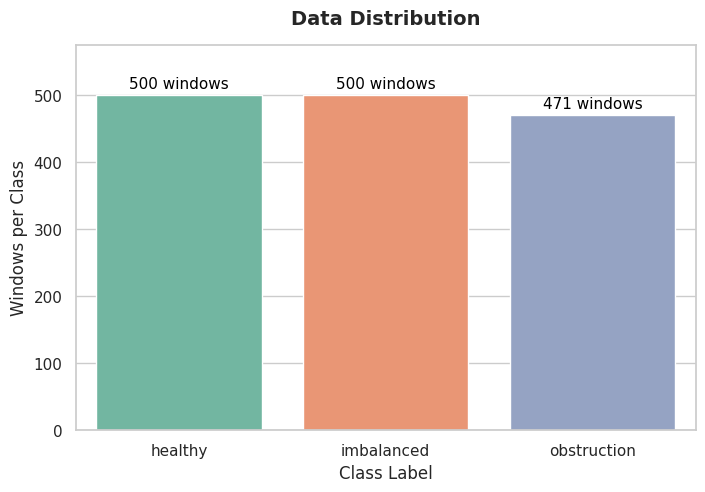

In [ ]:
#@title 1. Read preprocessed file:
# 1. Load the features generated by window.py and FFT_extraction.py
features_file = "features_for_deployment.csv"

if not os.path.exists(features_file):
    raise FileNotFoundError(
        f"Could not find '{features_file}'. Please run FFT_extraction.py first!"
    )

FILE_PATH = "features_for_deployment.csv"

df_master = pd.read_csv(features_file)
print(f"Dataset successfully loaded. Shape: {df_master.shape}")
print(df_master["label"].value_counts())

# 2. Strict alignment with raw_features[6] array order in IIR_deployment_Regression.ino
feature_columns = [
    "RMS_X",
    "RMS_Y",
    "RMS_Z",
    "Band_Power_Z_Low",
    "Band_Power_Z_Mid",
    "Band_Power_Z_High",
    "CrestFactor_Z",
    "Kurtosis_Z"
]

FEATURE_COLUMNS = [
    "RMS_X",
    "RMS_Y",
    "RMS_Z",
    "Band_Power_Z_Low",
    "Band_Power_Z_Mid",
    "Band_Power_Z_High",
    "CrestFactor_Z",
    "Kurtosis_Z"
]

X = df_master[feature_columns].values
y = df_master["label"].values

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Standard Scaler initialization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

try:
    df = pd.read_csv(FILE_PATH)
    print("[OK] Đã nạp dữ liệu thành công!\n")

    # Count the number of samples, as calculating their percentage:
    class_counts = df['label'].value_counts()
    class_percentages = df['label'].value_counts(normalize=True) * 100

    # A table for illustration:
    summary_df = pd.DataFrame({
        'The number of samples (Windows)': class_counts,
        'Percentage (%)': class_percentages
    })
    print("--- Satistical Table ---")
    print(summary_df.to_string())
    print("-" * 38)

    # Illustrate using bar chart:
    plt.figure(figsize=(8, 5))
    sns.set_theme(style="whitegrid")

    ax = sns.countplot(x='label', data=df, palette='Set2', hue='label', legend=False)

    # Show statistic on the head of each chart:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())} windows',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline',
                    fontsize=11, color='black',
                    xytext=(0, 5),
                    textcoords='offset points')

    plt.title('Data Distribution', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Class Label', fontsize=12)
    plt.ylabel('Windows per Class', fontsize=12)
    plt.ylim(0, max(class_counts) * 1.15)

    plt.show()

except FileNotFoundError:
    print(f"Unable to find the file!")


Successfully imported data!
Samples: 1471


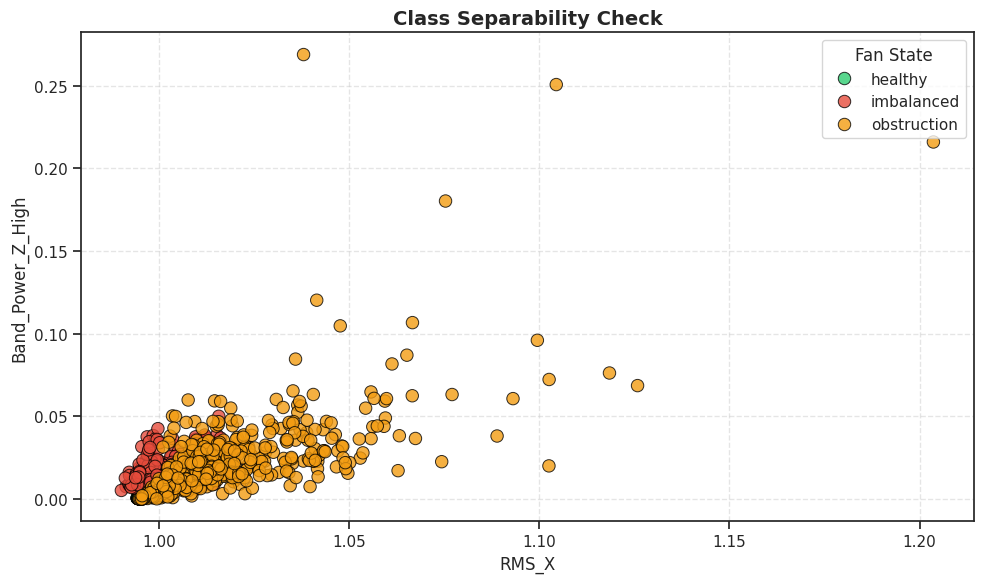

In [ ]:
#@title 2. Scatter Plot

try:
    df = pd.read_csv(FILE_PATH)

    print("Successfully imported data!")
    print(f"Samples: {len(df)}")

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="ticks")

    colors = {
        "healthy": "#2ecc71",
        "imbalanced": "#e74c3c",
        "obstruction": "#f39c12"
    }

    sns.scatterplot(
        data=df,
        x="RMS_X",
        y="Band_Power_Z_High",
        hue="label",
        palette=colors,
        alpha=0.8,
        s=80,
        edgecolor="black"
    )

    plt.title("Class Separability Check", fontsize=14, fontweight="bold")
    plt.xlabel("RMS_X")
    plt.ylabel("Band_Power_Z_High")

    plt.legend(title="Fan State")
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"File not found: {FILE_PATH}")

except KeyError as e:
    print(f"Missing column: {e}")
    print("Available columns:")
    print(df.columns.tolist())

[OK] Data loaded and time-axis synchronized successfully!



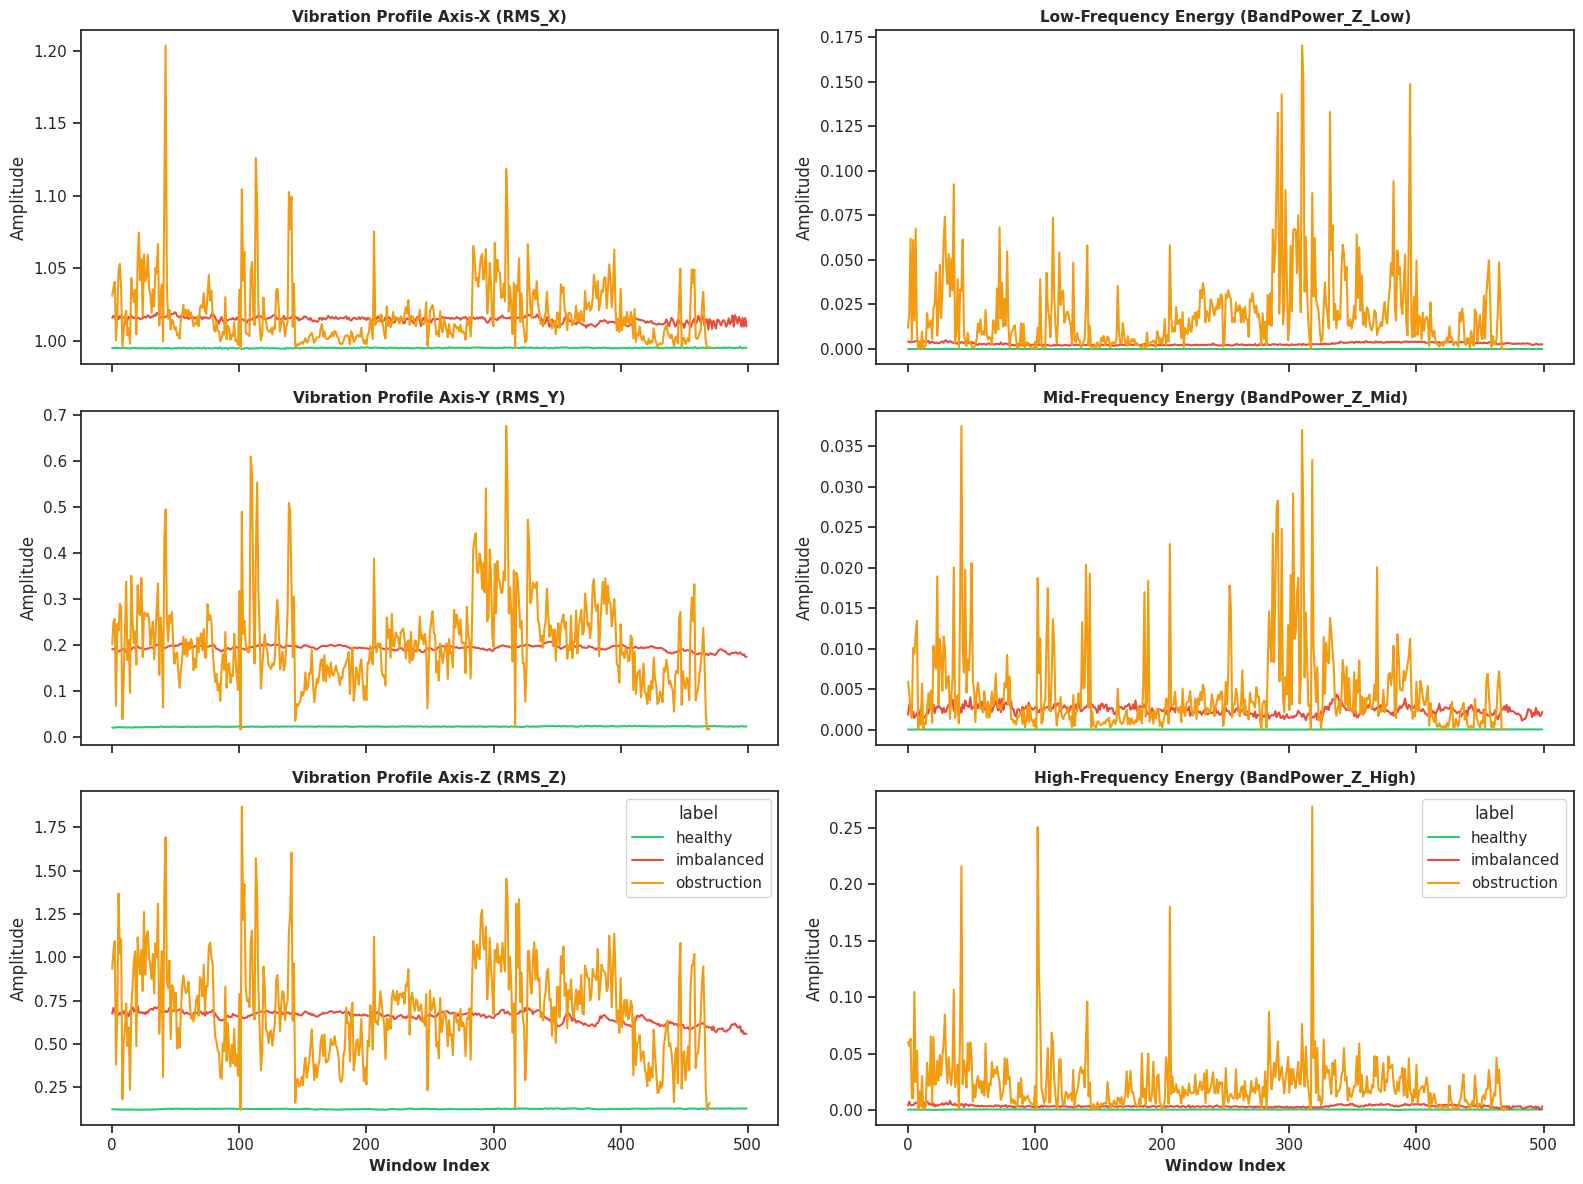

In [ ]:
#@title 3. Feature Reading
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv(FILE_PATH)

    # Synchronize time-axis by generating sequential Window Index per Class
    df['Window_Index'] = df.groupby('label').cumcount()
    print("[OK] Data loaded and time-axis synchronized successfully!\n")

    # Initialize Grid Plot: 3 rows (Axes/Bands) x 2 columns (Col 1: RMS, Col 2: BandPower)
    fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
    sns.set_theme(style="whitegrid")

    # Monolithic color palette for system-wide consistency
    colors = {"healthy": "#2ecc71", "imbalanced": "#e74c3c", "obstruction": "#f39c12"}

    # Target feature vectors for visualization
    rms_features = ['RMS_X', 'RMS_Y', 'RMS_Z']
    bp_features = ['Band_Power_Z_Low', 'Band_Power_Z_Mid', 'Band_Power_Z_High']

    titles_rms = ['Vibration Profile Axis-X (RMS_X)', 'Vibration Profile Axis-Y (RMS_Y)', 'Vibration Profile Axis-Z (RMS_Z)']
    titles_bp = ['Low-Frequency Energy (BandPower_Z_Low)', 'Mid-Frequency Energy (BandPower_Z_Mid)', 'High-Frequency Energy (BandPower_Z_High)']

    # Execution Loop: Generate 6 distinct subplots
    for i in range(3):
        # Column 1: Time-Domain Features (RMS)
        sns.lineplot(
            data=df, x='Window_Index', y=rms_features[i], hue='label',
            palette=colors, linewidth=1.5, ax=axes[i, 0]
        )
        axes[i, 0].set_title(titles_rms[i], fontsize=11, fontweight='bold')
        axes[i, 0].set_ylabel('Amplitude')
        # Redundant legend suppression to optimize layout visibility
        if i < 2: axes[i, 0].get_legend().remove()

        # Column 2: Frequency-Domain Features (BandPower)
        sns.lineplot(
            data=df, x='Window_Index', y=bp_features[i], hue='label',
            palette=colors, linewidth=1.5, ax=axes[i, 1]
        )
        axes[i, 1].set_title(titles_bp[i], fontsize=11, fontweight='bold')
        axes[i, 1].set_ylabel('Amplitude')
        if i < 2: axes[i, 1].get_legend().remove()

    # Configure X-Axis labels for the terminal plots only (Memory/Visual optimization)
    axes[2, 0].set_xlabel('Window Index', fontsize=11, fontweight='bold')
    axes[2, 1].set_xlabel('Window Index', fontsize=11, fontweight='bold')

    # Optimize padding parameters to prevent text overlap
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"[ERROR] Target file '{FILE_PATH}' missing. Execute the preprocessing pipeline first!")


[OK] All continuous RAW data streams loaded successfully!

=== 1. SIGNAL CLIPPING & SATURATION CHECK ===
[HEALTHY] Peak Amplitude -> X: 0.02, Y: 0.97, Z: 0.09 m/s^2
[IMBALANCED] Peak Amplitude -> X: 0.09, Y: 1.01, Z: 0.60 m/s^2
[OBSTRUCTION] Peak Amplitude -> X: 1.36, Y: 2.16, Z: 1.19 m/s^2
 -> [PASS] Signal headroom verified. Max amplitudes are within safe operating limits (< 156.96 m/s^2).

=== 2. NOISE FLOOR EVALUATION & SNR METRICS ===
Signal Power Variance (Axis-X):
 - Healthy State (Baseline Noise Floor): 0.0000
 - Imbalance State (Fault Signal Target):  0.0005 -> SNR = 11.90 dB
 - Obstruction State (Fault Signal Target): 0.0018 -> SNR = 17.68 dB
 -> [PASS] Fault signal power significantly dominates the noise floor.
           Linear ML models (e.g., Logistic Regression) will achieve clear separability.



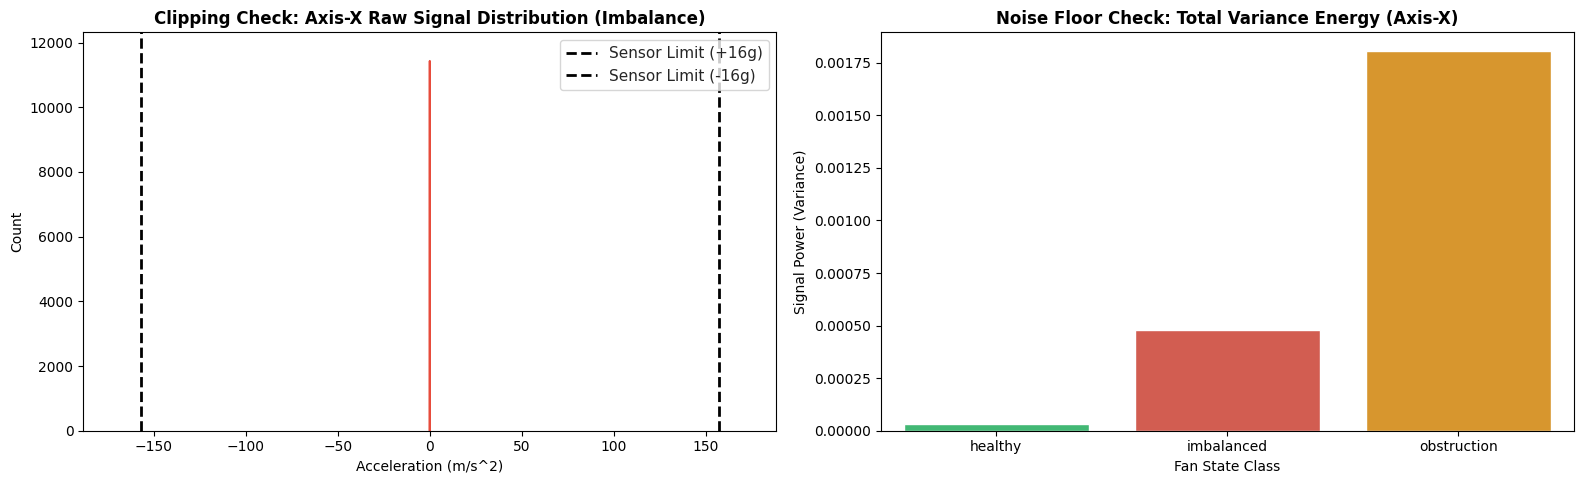

In [1]:
#@title 4. Clipping and Noise Floor Check:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAW_DIR = "raw"
MPU6050_LIMIT = 16.0 * 9.81  # Maximum physical scale threshold (+/- 16g)

classes = ["healthy", "imbalanced", "obstruction"]
raw_data = {}

# 1. Load continuous RAW stream dataset from the Acquisition Pipeline
for cls in classes:

    file_path = os.path.join(RAW_DIR, f"arduino_serial_data_{cls}.csv")
    if os.path.exists(file_path):
        raw_data[cls] = pd.read_csv(file_path)
    else:
        print(f"[WARNING] Raw data file not found: {file_path}")

if len(raw_data) == 3:
    print("[OK] All continuous RAW data streams loaded successfully!\n")

    # -----------------------------------------------------
    # STEP 1: SIGNAL CLIPPING DETECTION
    # -----------------------------------------------------
    print("=== 1. SIGNAL CLIPPING & SATURATION CHECK ===")
    clipping_detected = False

    for cls in classes:
        df_raw = raw_data[cls]
        # Evaluate absolute peak acceleration values across all three orthogonal axes
        max_x = np.max(np.abs(df_raw['accX']))
        max_y = np.max(np.abs(df_raw['accY']))
        max_z = np.max(np.abs(df_raw['accZ']))

        print(f"[{cls.upper()}] Peak Amplitude -> X: {max_x:.2f}, Y: {max_y:.2f}, Z: {max_z:.2f} m/s^2")

        # Trigger hardware saturation warning if peaks violate the +/-2g physical constraint
        if max_x >= MPU6050_LIMIT or max_y >= MPU6050_LIMIT or max_z >= MPU6050_LIMIT:
            print(f" -> [WARNING] Signal saturated the physical limit ({MPU6050_LIMIT:.2f} m/s^2). Waveform clipping occurred!")
            clipping_detected = True

    if not clipping_detected:
        print(f" -> [PASS] Signal headroom verified. Max amplitudes are within safe operating limits (< {MPU6050_LIMIT:.2f} m/s^2).\n")

    # -----------------------------------------------------
    # STEP 2: NOISE FLOOR & SIGNAL-TO-NOISE RATIO (SNR) ANALYSIS
    # -----------------------------------------------------
    print("=== 2. NOISE FLOOR EVALUATION & SNR METRICS ===")
    # Utilize variance of Axis-X to represent dynamic signal power
    power_healthy = np.var(raw_data['healthy']['accX'])
    power_imbalance = np.var(raw_data['imbalanced']['accX'])
    power_obstruction = np.var(raw_data['obstruction']['accX'])

    # Calculate Signal-to-Noise Ratio (SNR) in Decibels (dB)
    # The 'healthy' state is defined as the baseline mechanical and sensor noise floor
    snr_imbalance_db = 10 * np.log10(power_imbalance / power_healthy)
    snr_obstruction_db = 10 * np.log10(power_obstruction / power_healthy)

    print(f"Signal Power Variance (Axis-X):")
    print(f" - Healthy State (Baseline Noise Floor): {power_healthy:.4f}")
    print(f" - Imbalance State (Fault Signal Target):  {power_imbalance:.4f} -> SNR = {snr_imbalance_db:.2f} dB")
    print(f" - Obstruction State (Fault Signal Target): {power_obstruction:.4f} -> SNR = {snr_obstruction_db:.2f} dB")

    # Industry Rule of Thumb: SNR > 10dB (major faults) and > 3dB (minor faults) ensures linear separability
    if snr_imbalance_db > 10 and snr_obstruction_db > 3:
        print(" -> [PASS] Fault signal power significantly dominates the noise floor.")
        print("           Linear ML models (e.g., Logistic Regression) will achieve clear separability.\n")
    else:
        print(" -> [WARNING] Fault signature is weak; risk of signal degradation within the noise floor!\n")

    # -----------------------------------------------------
    # STEP 3: DIAGNOSTIC PLOT GENERATION
    # -----------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    sns.set_theme(style="whitegrid")

    # Subplot 1: Distribution Density (Histogram) to verify structural clipping/flattened peaks
    sns.histplot(raw_data['imbalanced']['accX'], ax=ax1, color='#e74c3c', kde=True, bins=50)
    ax1.axvline(x=MPU6050_LIMIT, color='black', linestyle='--', linewidth=2, label='Sensor Limit (+16g)')
    ax1.axvline(x=-MPU6050_LIMIT, color='black', linestyle='--', linewidth=2, label='Sensor Limit (-16g)')
    ax1.set_title('Clipping Check: Axis-X Raw Signal Distribution (Imbalance)', fontweight='bold')
    ax1.set_xlabel('Acceleration (m/s^2)')
    ax1.set_xlim(-MPU6050_LIMIT * 1.2, MPU6050_LIMIT * 1.2)
    ax1.legend()

    # Subplot 2: Energy comparison to evaluate statistical margin from the Noise Floor
    energies = [power_healthy, power_imbalance, power_obstruction]
    sns.barplot(x=classes, y=energies, palette=['#2ecc71', '#e74c3c', '#f39c12'], ax=ax2, hue=classes, legend=False)
    ax2.set_title('Noise Floor Check: Total Variance Energy (Axis-X)', fontweight='bold')
    ax2.set_ylabel('Signal Power (Variance)')
    ax2.set_xlabel('Fan State Class')

    plt.tight_layout()
    plt.show()
else:
    print(f"[WARNING] Not all raw data files found. Skipping raw signal analysis.")


In [ ]:
#@title 5. Scaler Normalisation + Label Encoder
import pandas as np
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

FILE_PATH = "features_for_deployment.csv"

FEATURE_COLUMNS = [
    "RMS_X", "RMS_Y", "RMS_Z",
    "Band_Power_Z_Low", "Band_Power_Z_Mid", "Band_Power_Z_High",
    "CrestFactor_Z", "Kurtosis_Z",
]
LABEL_COLUMN = "label"

# ── Load & clean ──────────────────────────────────────────────────────
df = pd.read_csv(FILE_PATH)
df = df.dropna(subset=FEATURE_COLUMNS + [LABEL_COLUMN])
print(f"Loaded: {df.shape[0]} samples, {df.shape[1]} columns")
print(df[LABEL_COLUMN].value_counts())

X = df[FEATURE_COLUMNS].values
y = df[LABEL_COLUMN].values

# ── Train/test split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ── Scaler ────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── LabelEncoder ─────────────────────────────────────────────
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print(f"\n[OK] Scaler fit xong. Mean: {scaler.mean_.round(4)}")
print(f"[OK] Classes: {le.classes_}")
print(f"[OK] X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")

Loaded: 1471 samples, 11 columns
label
healthy        500
imbalanced     500
obstruction    471
Name: count, dtype: int64

[OK] Scaler fit xong. Mean: [1.0045 0.1248 0.618  0.0095 0.004  0.0132 2.8359 0.2386]
[OK] Classes: ['healthy' 'imbalanced' 'obstruction']
[OK] X_train: (1176, 8), X_test: (295, 8)


In [ ]:
#@title 6. Logistic Regression Training
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    multi_class=
'multinomial', solver='lbfgs',
    max_iter=2000, random_state=42
)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00       100
  imbalanced       1.00      1.00      1.00       100
 obstruction       1.00      1.00      1.00        95

    accuracy                           1.00       295
   macro avg       1.00      1.00      1.00       295
weighted avg       1.00      1.00      1.00       295



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classification Report


,precision,recall,f1-score,support
healthy,1.0,1.0,1.0,100.0
imbalanced,1.0,1.0,1.0,100.0
obstruction,1.0,1.0,1.0,95.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,295.0
weighted avg,1.0,1.0,1.0,295.0


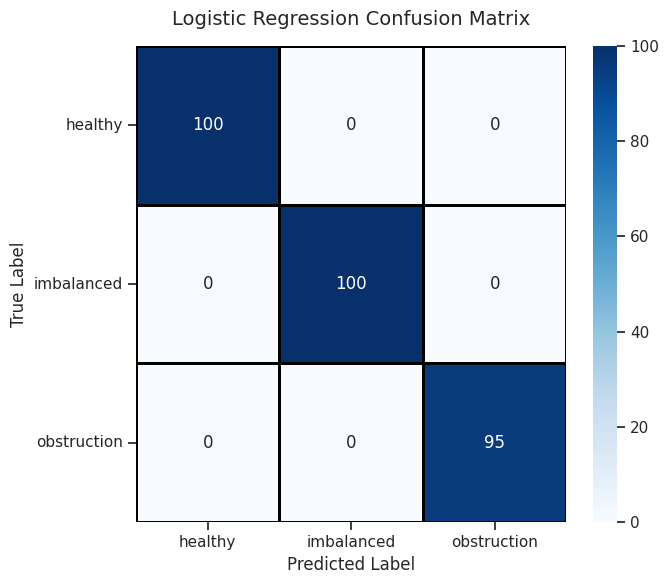


Class: healthy
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000

Class: imbalanced
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000

Class: obstruction
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000
Test Accuracy: 1.0000


In [ ]:
# @title 7. Logistic Regression Report + Confusion Matrix

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# =========================
# Predictions
# =========================
y_pred = lr_model.predict(X_test_scaled)

# =========================
# Classification Report
# =========================
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("Classification Report")
display(report_df)

# =========================
# Confusion Matrix
# =========================
classes = ['healthy', 'imbalanced', 'obstruction']

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=classes
)

# =========================
# Plot Confusion Matrix
# =========================
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    cbar=True,
    linewidths=1,
    linecolor='black'
)

plt.title('Logistic Regression Confusion Matrix',
          fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================
# Per-class Metrics
# =========================
for cls in classes:
    print(f"\nClass: {cls}")
    print(f"Precision : {report[cls]['precision']:.4f}")
    print(f"Recall    : {report[cls]['recall']:.4f}")
    print(f"F1-score  : {report[cls]['f1-score']:.4f}")

print("=" * 80)

# =========================
# Overall Accuracy
# =========================
test_acc = lr_model.score(X_test_scaled, y_test)

print(f"Test Accuracy: {test_acc:.4f}")

In [ ]:
#@title 8. Install LR model to deploy
import numpy as np

# Cast parameters safely to 32-bit floats for the ESP32 Hardware FPU
means = scaler.mean_.astype(np.float32)
stds = scaler.scale_.astype(np.float32)

# 🛠️ Logic Reinforcement 1: Zero-division Protection
# If STD is 0, force it to 1.0f so that the division (x - mean) / 1.0f does not alter the value or cause a crash.
stds = np.where(stds == 0.0, 1.0, stds)

W = lr_model.coef_.astype(np.float32)
b = lr_model.intercept_.astype(np.float32)

# 🛠️ Logic Reinforcement 2: Handling the edge case where the model collapses into a binary classifier (Binary Classifier Shape Sync)
# If the matrix has only one row (binary classification scenario), duplicate the complementary row to ensure compatibility with the multi-class C++ implementation.
if W.shape[0] == 1:
    W = np.vstack([-W, W])
    b = np.array([-b[0], b[0]], dtype=np.float32)

n_classes, n_features = W.shape

# 3. Build the C++ header structural framework
cpp_header = """/*
 * model_parameters.h
 * Auto-generated header file for ESP32 edge deployment.
 * Architecture: Logistic Regression (Multi-class Sync)
 * Optimization: Memory-mapped to Flash ROM via 'const' definitions.
 * DO NOT MODIFY THIS FILE MANUALLY.
 */

#ifndef MODEL_PARAMETERS_H
#define MODEL_PARAMETERS_H

#include <stdint.h>

#define MODEL_NUM_CLASSES   {n_classes}
#define MODEL_NUM_FEATURES  {n_features}

// ==============================================================================
// RUNTIME DATA NORMALIZATION (STANDARDSALER OVERHEAD SYNC)
// ==============================================================================
const float SCALER_MEAN[MODEL_NUM_FEATURES] = {{ {means_str} }};
const float SCALER_STD[MODEL_NUM_FEATURES]  = {{ {stds_str} }};

// ==============================================================================
// LOGISTIC REGRESSION WEIGHT MATRICES & BIAS VECTORS
// ==============================================================================
const float LGR_WEIGHTS[MODEL_NUM_CLASSES][MODEL_NUM_FEATURES] = {{
""".format(
    n_classes=n_classes,
    n_features=n_features,
    means_str=", ".join([f"{m:.6f}f" for m in means]),
    stds_str=", ".join([f"{s:.6f}f" for s in stds])
)

# Append weight arrays
for idx, class_weights in enumerate(W):
    weights_str = ", ".join([f"{w:.6f}f" for w in class_weights])
    # Tránh lỗi index vượt biên nếu mô hình nhị phân gốc chỉ có 1 nhãn lớp công khai
    class_label = lr_model.classes_[idx] if idx < len(lr_model.classes_) else f"Inverted_Class_{idx}"
    cpp_header += f"    {{ {weights_str} }}, // Class {idx} Target: {class_label}\n"

cpp_header += "};\n\n"

# Append bias vectors
biases_str = ", ".join([f"{bias:.6f}f" for bias in b])
cpp_header += f"const float LGR_BIASES[MODEL_NUM_CLASSES] = {{ {biases_str} }};\n\n"

# Metadata labels for embedded logging interface
cpp_header += "const char* const MODEL_CLASS_LABELS[MODEL_NUM_CLASSES] = {\n"
if len(lr_model.classes_) == 2 and n_classes == 2:
    cpp_header += f'    "Not_{lr_model.classes_[1]}",\n'
    cpp_header += f'    "{lr_model.classes_[1]}",\n'
else:
    for class_label in lr_model.classes_:
        cpp_header += f'    "{class_label}",\n'
cpp_header += "}; alienation\n"

cpp_header += "\n#endif // MODEL_PARAMETERS_H\n"

# Commit output buffer safely to disk
OUTPUT_FILENAME = "model_parameters.h"
with open(OUTPUT_FILENAME, "w") as f:
    f.write(cpp_header)

print(f"[SUCCESS] Guarded parameters committed to '{OUTPUT_FILENAME}'. ready for edge deployment.")

[SUCCESS] Guarded parameters committed to 'model_parameters.h'. ready for edge deployment.


In [ ]:
#@title 9. Small Dense Neural Network Architecture Declaration
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Dense(16, activation='relu', input_shape=(8,)),
    Dense(8,  activation='relu'),
    Dense(3,  activation='softmax'),
])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307 (1.20 KB)

 Trainable params: 307 (1.20 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title 10. Small Dense Neural Network Training
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_encoded,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7511 - loss: 0.8988 - val_accuracy: 0.9153 - val_loss: 0.7445
Epoch 2/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9287 - loss: 0.5985 - val_accuracy: 0.9280 - val_loss: 0.4666
Epoch 3/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9383 - loss: 0.3419 - val_accuracy: 0.9364 - val_loss: 0.2750
Epoch 4/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9585 - loss: 0.2004 - val_accuracy: 0.9534 - val_loss: 0.1768
Epoch 5/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9745 - loss: 0.1293 - val_accuracy: 0.9661 - val_loss: 0.1217
Epoch 6/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9798 - loss: 0.0924 - val_accuracy: 0.9703 - val_loss: 0.0918
Epoch 7/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9840 - loss: 0.0715 - val_accuracy: 0.9788 - val_loss: 0.0734
Epoch 8/300
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9872 - loss: 0.0578 - val_accuracy: 0.9873 - v

In [ ]:
#@title 11. Small Dense Neural Network's Accuracy:
test_loss, test_acc = model.evaluate(
    X_test_scaled,
    y_test_encoded,
    verbose=0
)

print(f"Test Accuracy: {test_acc:.4f}")



Test Accuracy: 1.0000


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


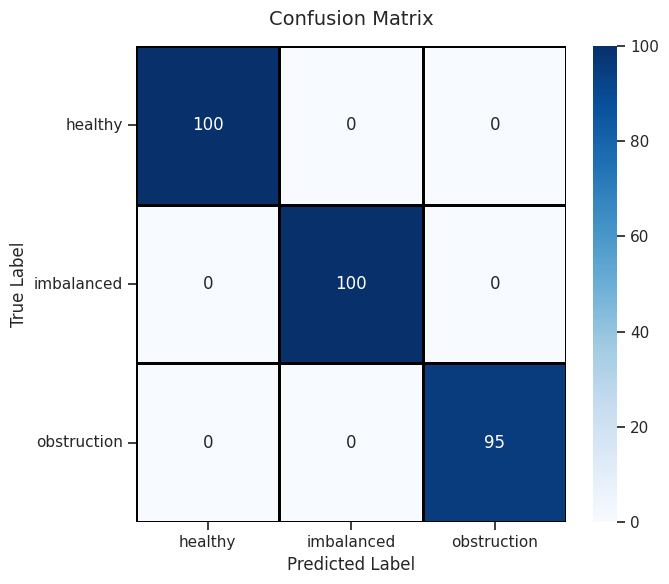


Class: healthy
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000

Class: imbalanced
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000

Class: obstruction
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000
Test Accuracy: 1.0000


In [ ]:
# @title 12. Prediction Cell Report + Classification Report of Small Dense Neural Network

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred_encoded = y_pred_prob.argmax(axis=1)

# Decode labels
y_pred = le.inverse_transform(y_pred_encoded)
y_test_decoded = le.inverse_transform(y_test_encoded)

# Classification report
report = classification_report(
    y_test_decoded,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Confusion Matrix
classes = ['healthy', 'imbalanced', 'obstruction']
cm = confusion_matrix(
    y_test_decoded,
    y_pred,
    labels=classes
)

# Plot
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    cbar=True,
    linewidths=1,
    linecolor='black'
)

plt.title('Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class metrics
for cls in classes:
    print(f"\nClass: {cls}")
    print(f"Precision : {report[cls]['precision']:.4f}")
    print(f"Recall    : {report[cls]['recall']:.4f}")
    print(f"F1-score  : {report[cls]['f1-score']:.4f}")

print("=" * 80)
print(f"Test Accuracy: {test_acc:.4f}")

Plot saved successfully as 'model_training_history.png'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

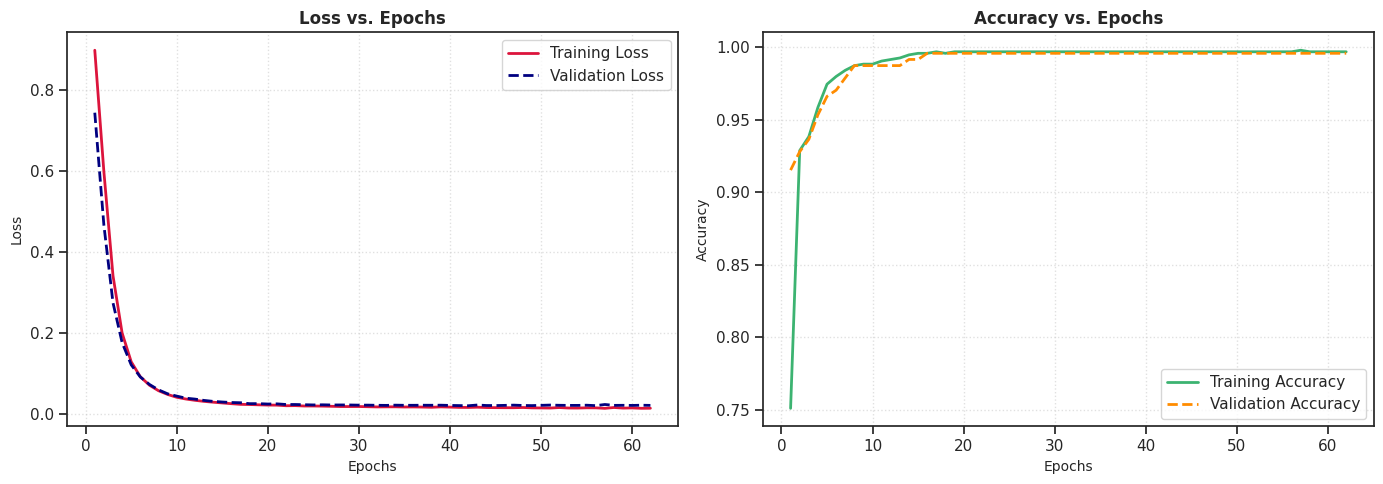

Small Dense NN Test Accuracy: 1.0000


In [ ]:
#@title 13. Visualize learning curve of Small Dense NN:
import matplotlib.pyplot as plt
# If you are in Google Colab, you can also import files to download automatically
try:
    from google.colab import files
except ImportError:
    files = None

# Retrieve loss and accuracy metrics from history log
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'

training_acc = history.history[acc_key]
validation_acc = history.history[val_acc_key]

epochs_range = range(1, len(training_loss) + 1)

# Set up the matplotlib figure layout
fig = plt.figure(figsize=(14, 5))

# Plot 1: Loss vs. Epochs
plt.subplot(1, 2, 1)
plt.plot(epochs_range, training_loss, label='Training Loss', color='crimson', linewidth=2)
plt.plot(epochs_range, validation_loss, label='Validation Loss', color='navy', linestyle='--', linewidth=2)
plt.title('Loss vs. Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Accuracy vs. Epochs
plt.subplot(1, 2, 2)
plt.plot(epochs_range, training_acc, label='Training Accuracy', color='mediumseagreen', linewidth=2)
plt.plot(epochs_range, validation_acc, label='Validation Accuracy', color='darkorange', linestyle='--', linewidth=2)
plt.title('Accuracy vs. Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# --- NEW: SAVE THE PLOT TO YOUR WORKSPACE ---
# dpi=300 ensures the image is high-resolution for reports/presentations
filename = "model_training_history.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully as '{filename}'")

# --- NEW: AUTOMATIC DOWNLOAD (If using Google Colab) ---
if files is not None:
    files.download(filename)

plt.show()

nn_accuracy = test_acc
print(f"Small Dense NN Test Accuracy: {nn_accuracy:.4f}")

In [ ]:
#@title 14. Export C++ Header for Small Dense NN (8-Feature Version)
import numpy as np
weights = model.get_weights()

if len(weights) != 6:
    raise ValueError(
        f"Cấu trúc mạng không khớp: kỳ vọng 6 tensor (3 cặp W/B), "
        f"nhận được {len(weights)}. Kiểm tra lại model.summary()."
    )


W1, B1, W2, B2, W3, B3 = weights

# ── Check each layers ─────────────────────────────────────

# FIX: Added shape assertions to catch errors early if the architecture changes
#      Keras stores W as (input_dim, output_dim), so:
#        W1: (8, 16)  W2: (16, 8)  W3: (8, 3)
assert W1.shape == (8, 16),  f"W1 shape sai: {W1.shape}, kỳ vọng (8, 16)"
assert W2.shape == (16, 8),  f"W2 shape sai: {W2.shape}, kỳ vọng (16, 8)"
assert W3.shape == (8, 3),   f"W3 shape sai: {W3.shape}, kỳ vọng (8, 3)"
assert B1.shape == (16,),    f"B1 shape sai: {B1.shape}"
assert B2.shape == (8,),     f"B2 shape sai: {B2.shape}"
assert B3.shape == (3,),     f"B3 shape sai: {B3.shape}"


# ── 3. Read config from scaler ───────────────────────────────────────────
n_features = scaler.mean_.shape[0]   # = 8
n_classes  = B3.shape[0]            # = 3

means = scaler.mean_.astype(np.float32)
stds  = scaler.scale_.astype(np.float32)
stds  = np.where(stds == 0.0, 1.0, stds)  # zero-division guard

# ── 4. Cast weights to float32 ───────────────────────────────────────
W1 = W1.astype(np.float32)
W2 = W2.astype(np.float32)
W3 = W3.astype(np.float32)
B1 = B1.astype(np.float32)
B2 = B2.astype(np.float32)
B3 = B3.astype(np.float32)

# ── 5. Helper: chuyển matrix thành chuỗi C array 2D ─────────────────
def matrix_to_c(M: np.ndarray) -> str:
    """Ghi mỗi hàng của M ra 1 dòng C-array, kết thúc bằng ','."""
    rows = []
    for row in M:
        vals = ", ".join([f"{v:.8f}f" for v in row])
        rows.append(f"    {{ {vals} }},")
    return "\n".join(rows)

# ── 6. Processing transpose ───────────────────────────────────────────────

# FIX: Keras W shape = (input_dim, output_dim)
#      ESP32 C++:  output[j] = sum_i( W_c[j][i] * input[i] ) + B[j]
#      This means W_c[j][i] = W_keras[i][j]  →  W_c = W_keras.T
#      Therefore, transposition is required when writing to the header — this is CORRECT.
#      However, this is only valid if the C++ code uses the loop structure: for j: for i: W[j][i]*in[i]
W1_c = W1.T   # (8,16).T  → (16,8)  ← W1_c[neuron_out][feature_in]
W2_c = W2.T   # (16,8).T  → (8,16)  ← W2_c[neuron_out][neuron_in]
W3_c = W3.T   # (8,3).T   → (3,8)   ← W3_c[class][neuron_in]



# QUICK CHECK: Run Python vs. C-order forward pass to verify.
def relu(x): return np.maximum(0, x)

sample   = X_test_scaled[0].astype(np.float32)
h1_keras = relu(W1.T @ sample + B1)           # chiều Python (kiểm chứng)
h1_c     = np.array([np.dot(W1_c[j], sample) + B1[j] for j in range(16)])
h1_c     = relu(h1_c)
assert np.allclose(h1_keras, h1_c, atol=1e-5), "W1 transpose sai chiều!"
print("[OK] Forward-pass C-order khớp với Keras")


# ── 7. Retrieve labels according to the LabelEncoder order ───────────────────────

# FIX: Always use le.classes_ (after fitting) to ensure class index synchronization
#      Order: le.classes_[0]=healthy, [1]=imbalanced, [2]=obstruction
class_labels = le.classes_.tolist()
print(f"Class order: {class_labels}")


# ── header C++ ───────────────────────────────────────────────
cpp_header = f"""/*
 * model_parameters.h
 * Auto-generated — DO NOT EDIT MANUALLY.
 * Architecture : MLP 3-layer [{n_features} -> 16 -> 8 -> {n_classes}]
 * Activation   : ReLU (hidden), Softmax (output)
 * Convention   : W[output_neuron][input_neuron]  (row-major dot product)
 * Generated by : notebook export cell (8-feature version)
 */

#ifndef MODEL_PARAMETERS_H
#define MODEL_PARAMETERS_H

#include <stdint.h>

#define MODEL_NUM_FEATURES  {n_features}
#define MODEL_NUM_CLASSES   {n_classes}

/* Standardization — apply BEFORE inference */
const float SCALER_MEAN[MODEL_NUM_FEATURES] = {{
    {", ".join([f"{x:.8f}f" for x in means])}
}};
const float SCALER_STD[MODEL_NUM_FEATURES] = {{
    {", ".join([f"{x:.8f}f" for x in stds])}
}};

/* Layer 1 : {n_features} -> 16  (ReLU) */
const float W1[16][MODEL_NUM_FEATURES] = {{
{matrix_to_c(W1_c)}
}};
const float B1[16] = {{ {", ".join([f"{x:.8f}f" for x in B1])} }};

/* Layer 2 : 16 -> 8  (ReLU) */
const float W2[8][16] = {{
{matrix_to_c(W2_c)}
}};
const float B2[8] = {{ {", ".join([f"{x:.8f}f" for x in B2])} }};

/* Layer 3 : 8 -> {n_classes}  (Softmax) */
const float W3[MODEL_NUM_CLASSES][8] = {{
{matrix_to_c(W3_c)}
}};
const float B3[MODEL_NUM_CLASSES] = {{ {", ".join([f"{x:.8f}f" for x in B3])} }};

/* Class labels — index matches LabelEncoder.classes_ */
const char* const MODEL_CLASS_LABELS[MODEL_NUM_CLASSES] = {{
    {chr(10).join([f'    "{lbl}",' for lbl in class_labels])}
}};

#endif /* MODEL_PARAMETERS_H */
"""

# ── 9. Ghi file ──────────────────────────────────────────────────────
OUTPUT = "model_parameters.h"
with open(OUTPUT, "w", encoding="utf-8") as f:
    f.write(cpp_header)

print(f"[SUCCESS] '{OUTPUT}' đã được tạo.")
print(f"  Features : {n_features}")
print(f"  Classes  : {n_classes} → {class_labels}")
print(f"  W1_c     : {W1_c.shape}  (transposed từ {W1.shape})")
print(f"  W2_c     : {W2_c.shape}  (transposed từ {W2.shape})")
print(f"  W3_c     : {W3_c.shape}  (transposed từ {W3.shape})")

[OK] Forward-pass C-order khớp với Keras
Class order: ['healthy', 'imbalanced', 'obstruction']
[SUCCESS] 'model_parameters.h' đã được tạo.
  Features : 8
  Classes  : 3 → ['healthy', 'imbalanced', 'obstruction']
  W1_c     : (16, 8)  (transposed từ (8, 16))
  W2_c     : (8, 16)  (transposed từ (16, 8))
  W3_c     : (3, 8)  (transposed từ (8, 3))


In [ ]:
import pandas as pd
import numpy as np

# Đọc 1 file window healthy bất kỳ
df = pd.read_csv("hehe.csv")  # đổi path

signal = df["accZ_filt"].values.astype(float)
hann = np.hanning(len(signal))
windowed = signal * hann

print(f"Window size       : {len(signal)}")
print(f"Total Z energy    : {np.sum(windowed**2):.8f}")

# Tính luôn band power để so sánh
freqs, mag = np.fft.rfftfreq(len(signal), d=1/500), np.abs(np.fft.rfft(windowed)) / len(signal)
mask_low  = (freqs >= 50)  & (freqs < 80)
mask_mid  = (freqs >= 110) & (freqs < 140)
mask_high = (freqs >= 170) & (freqs <= 210)
print(f"BP_Z_Low          : {np.sum(mag[mask_low]**2):.8f}")
print(f"BP_Z_Mid          : {np.sum(mag[mask_mid]**2):.8f}")
print(f"BP_Z_High         : {np.sum(mag[mask_high]**2):.8f}")

Window size       : 128
Total Z energy    : 29.29873315
BP_Z_Low          : 0.01135337
BP_Z_Mid          : 0.00741596
BP_Z_High         : 0.04302390


STARTING EXTRACTION PIPELINE FOR DEPLOYMENT MODEL (FIXED)
[LOG 1] Đọc file thành công. Dung lượng: 3759 ký tự.
[LOG 2] Đã cô lập vùng chứa dữ liệu của biến W1.
[LOG 3] Đã chuyển đổi thành công 96 số thực.
[LOG 4] Khởi tạo ma trận [16][6] thành công.
[LOG 5] Đang vẽ biểu đồ...
SUCCESS: BIỂU ĐỒ ĐÃ ĐƯỢC XUẤT THÀNH CÔNG


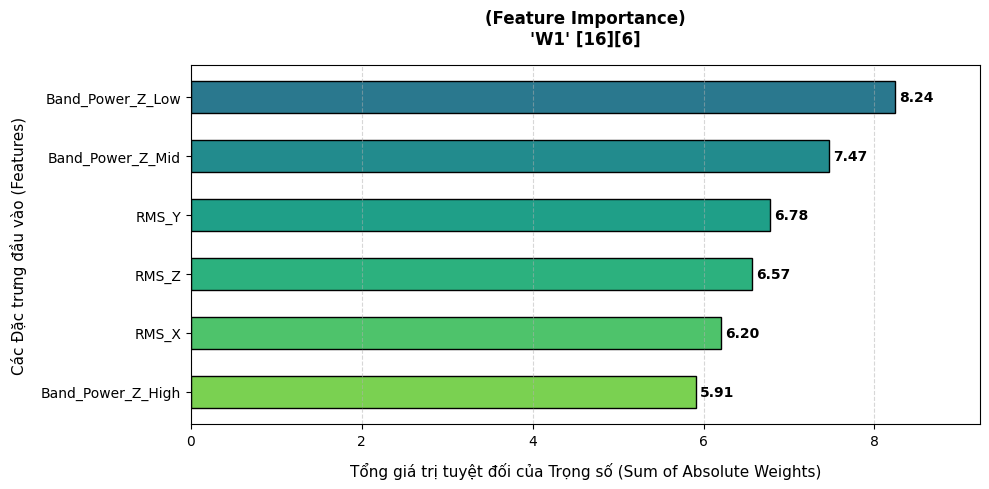

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np

# 1. Định nghĩa danh sách 6 đặc trưng đầu vào đúng theo thứ tự thực tế của file .h
feature_columns = [
    "RMS_X",
    "RMS_Y",
    "RMS_Z",
    "Band_Power_Z_Low",
    "Band_Power_Z_Mid",
    "Band_Power_Z_High"
]

file_path = "model_parameters.h"

print("=" * 70)
print("STARTING EXTRACTION PIPELINE FOR DEPLOYMENT MODEL (FIXED)")
print("=" * 70)

try:
    with open(file_path, "r") as f:
        content = f.read()

    print(f"[LOG 1] Đọc file thành công. Dung lượng: {len(content)} ký tự.")

    # Bước 1: Định vị biến W1 trong file .h
    target_variable_name = "W1"
    start_idx = content.find(target_variable_name)
    if start_idx == -1:
        raise ValueError("Không tìm thấy biến 'W1' trong file. Vui lòng kiểm tra lại file parameters.h")

    # Bước 2: Bóc tách vùng dữ liệu nằm trong dấu ngoặc nhọn lớn ngoài cùng của W1
    bracket_start = content.find("{", start_idx)
    bracket_end = content.find("};", bracket_start) # Tìm đến ký tự kết thúc mảng hẳn

    if bracket_start == -1 or bracket_end == -1:
        # Thử tìm kiếm dấu đóng ngoặc đơn thuần nếu không có dấu chấm phẩy sát cạnh
        bracket_end = content.find("}", bracket_start)
        if bracket_end == -1:
            raise ValueError("Cấu trúc mảng W1 không tuân thủ cú pháp C/C++ (thiếu dấu ngoặc { }).")

    raw_array_str = content[bracket_start + 1 : bracket_end]
    print(f"[LOG 2] Đã cô lập vùng chứa dữ liệu của biến W1.")

    # Bước 3: Làm sạch chuỗi dữ liệu thô
    # XÓA BỎ THÊM DẤU NHOẶC NHỌN NỘI BỘ '{' VÀ '}' ĐỂ TRÁNH LỖI ÉP KIỂU MẢNG 2 CHIỀU
    clean_str = (
        raw_array_str.replace("\n", "")
        .replace("\r", "")
        .replace(" ", "")
        .replace("{", "")
        .replace("}", "")
        .replace("f", "")
        .replace("F", "")
    )
    all_numbers = [float(x) for x in clean_str.split(",") if x.strip()]
    print(f"[LOG 3] Đã chuyển đổi thành công {len(all_numbers)} số thực.")

    # Bước 4: Kiểm tra số lượng phần tử (16 nodes x 6 features = 96 số)
    expected_elements = 16 * 6
    if len(all_numbers) < expected_elements:
        raise ValueError(
            f"Mảng W1 chỉ trích xuất được {len(all_numbers)} phần tử, "
            f"không đủ kích thước 96 cho ma trận [16][6] cấu hình hiện tại."
        )

    # Cấu trúc lại thành ma trận numpy [16][6]
    all_numbers = all_numbers[:expected_elements]
    weights_matrix = np.array(all_numbers).reshape(16, 6)
    print("[LOG 4] Khởi tạo ma trận [16][6] thành công.")

    # Bước 5: Tính tầm quan trọng đặc trưng bằng tổng trị tuyệt đối theo cột
    feature_importance = np.sum(np.abs(weights_matrix), axis=0)

    # Sắp xếp theo thứ tự giảm dần
    sorted_indices = np.argsort(feature_importance)[::-1]
    sorted_features = [feature_columns[i] for i in sorted_indices]
    sorted_importance = feature_importance[sorted_indices]

    # Bước 6: Render biểu đồ thanh ngang
    print("[LOG 5] Đang vẽ biểu đồ...")
    plt.figure(figsize=(10, 5))
    colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(sorted_importance)))

    bars = plt.barh(
        sorted_features[::-1],
        sorted_importance[::-1],
        color=colors[::-1],
        edgecolor="black",
        height=0.55,
    )

    # Ghi giá trị số cụ thể lên đầu mỗi thanh
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.2f}",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold",
        )

    plt.title(
        "(Feature Importance)\n"
        "'W1' [16][6]",
        fontsize=12,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Tổng giá trị tuyệt đối của Trọng số (Sum of Absolute Weights)", fontsize=11, labelpad=10)
    plt.ylabel("Các Đặc trưng đầu vào (Features)", fontsize=11, labelpad=10)
    plt.xlim(0, max(feature_importance) + 1.0)
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()

    print("=" * 70)
    print("SUCCESS: BIỂU ĐỒ ĐÃ ĐƯỢC XUẤT THÀNH CÔNG")
    print("=" * 70)
    plt.show()

except Exception as e:
    print(f"\n[FATAL ERROR] Quá trình xử lý thất bại:")
    print(f"👉 {e}")